In [1]:
import boto3
import s3fs
import zarr
import torch
from torch_geometric.data import Data

import cv2 as cv
import seaborn as sns
import matplotlib.pyplot as plt

from src.train_cnn import ResNetUNet
from src.train_gat import FloorplanGNN
from src.utils import *

s3 = boto3.client("s3")

In [2]:
%store -r

# Extracting Model Artifacts

In [3]:
STATE_DICT_CNN = f"{s3_project_prefix}/models/model_artifacts/pipelines-we82lejaox5y-TrainInteriorBoundsM-i8k96yaPTB/output/model.tar.gz"
STATE_DICT_GAT = f"{s3_project_prefix}/models/model_artifacts/gat/pipelines-g74eu4gn1fgf-TrainGATModel-ajs5kHDnKX/output/model.tar.gz"

archive_path = 'model.tar.gz'
state_dict_path = "model_best.pth"
resnet_extract_dir = './extracted_model/resnet'
gnn_extract_dir = './extracted_model/gnn'

In [4]:
cnn_state_dict_path = download_and_extract_state_dict(STATE_DICT_CNN, 
                                                      model_artifact=archive_path,
                                                      state_dict_path=state_dict_path,
                                                      extract_dir=resnet_extract_dir)

gat_state_dict_path = download_and_extract_state_dict(STATE_DICT_GAT,
                                                      model_artifact=archive_path,
                                                      state_dict_path=state_dict_path,
                                                      extract_dir=gnn_extract_dir)

Extracting to ./extracted_model/resnet ...
Found model_best.pth at ./extracted_model/resnet/model_best.pth
Extracting to ./extracted_model/gnn ...
Found model_best.pth at ./extracted_model/gnn/model_best.pth


In [5]:
cnn_state_dict_path

'./extracted_model/resnet/model_best.pth'

In [6]:
cnn_model = model_fn(cnn_state_dict_path, ResNetUNet())
gat_model = model_fn(gat_state_dict_path, FloorplanGNN())

# Inference

In [7]:
val_indices = np.load("val_indices.npy")

# Open the S3 filesystem
fs = s3fs.S3FileSystem()

# Open the zarr store
store = s3fs.S3Map(root=f'{s3_project_prefix}/store/data.zarr', s3=fs, check=False)

# Open the zarr array or group
z = zarr.open(store, mode='r')

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7f9ed69a7e60>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7f9ed6827ad0>, 6328.732291806)])']
connector: <aiohttp.connector.TCPConnector object at 0x7f9ed68891f0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7f9ec5033d70>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7f9ed6826270>, 6328.724281998)])']
connector: <aiohttp.connector.TCPConnector object at 0x7f9ed67c0260>


In [8]:
# Load sample
val_idx = val_indices[10]

boundary_mask_gt = z['boundary_masks'][val_idx]
inside_mask_gt = z['inside_masks'][val_idx]
room_mask_gt = z['room_masks'][val_idx]
door_mask_gt = z['door_masks'][val_idx]

boundary_mask_in = torch.Tensor(boundary_mask_gt).to('cpu').float().unsqueeze(0)  # (H,W) -> (1,H,W)
inside_mask_in   = torch.Tensor(inside_mask_gt).to('cpu').float().unsqueeze(0)    # (H,W) -> (1,H,W)

## Stage 1: Generate Interior Boundaries

In [9]:
with torch.no_grad():
    pred = cnn_model(inside_mask_in, boundary_mask_in)

# Output is (1, 1, H, W) — squeeze back down for visualization
pred_room = torch.sigmoid(pred['room_mask']).squeeze().numpy()  # (H,W)
pred_door = torch.sigmoid(pred['door_mask']).squeeze().numpy() 

In [10]:
pred_room_bin = model_thresholding(pred_room, 0.20)
pred_door_bin = model_thresholding(pred_door, 0.15)

pred_post_processed = post_process_stacked_layers(pred_room_bin, pred_door_bin)

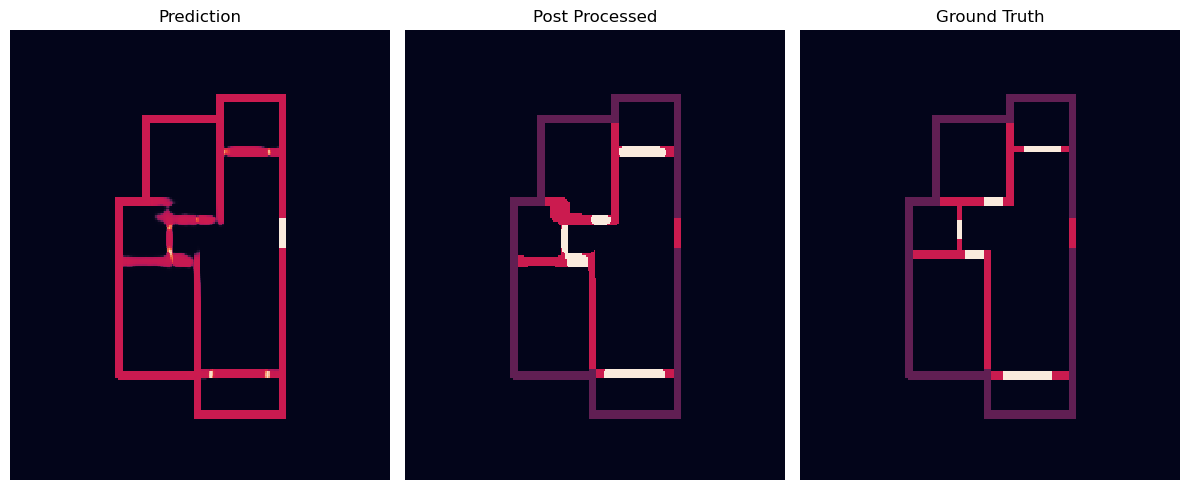

In [11]:
input_arrs = np.sum([boundary_mask_gt, room_mask_gt*2, door_mask_gt*4], axis=0)
stacked_layers_nt = np.sum([pred_room, pred_door], axis=0)

fig, ax = plt.subplots(1, 3, figsize=(12, 5))

sns.heatmap(np.sum([boundary_mask_gt, stacked_layers_nt], axis=0), ax=ax[0], 
            cbar=False, xticklabels=False, yticklabels=False)
ax[0].set_title("Prediction")

sns.heatmap(np.sum([boundary_mask_gt, pred_post_processed], axis=0), ax=ax[1], 
            cbar=False, xticklabels=False, yticklabels=False)
ax[1].set_title("Post Processed")

sns.heatmap(input_arrs, 
            cbar=False, xticklabels=False, yticklabels=False)
ax[2].set_title("Ground Truth")

plt.tight_layout()
plt.show()

## Stage 2: Graph Extraction & Node Prediction

In [12]:
# Graph extraction
stacked_layers = stack_normalize(boundary_mask_gt, pred_room_bin, pred_door_bin)
num_labels, labels, stats, centroids = conn_components(
	inside_mask_gt, boundary_mask_gt, pred_room_bin, pred_door_bin
	)
rwb = rooms_with_bounds(stacked_layers, labels)
adj_graph = extract_all_adjacencies(rwb)
src, dst, attr = edge_arrays(adj_graph)

edge_index = np.array([src, dst])
edge_attr = np.array(attr)
node_features = np.array(node_array(centroids[1:, :], stats[1:, :]))

In [13]:
adj_graph

,n1,n2,adj_type,edge_strength
0,5,6,0,14
2,5,7,1,28
4,6,7,1,8
5,6,8,0,17
7,7,8,1,11
8,7,9,0,62
10,7,10,1,35
11,8,9,0,30


In [14]:
node_features

array([[ 162.07807487,   53.13903743,  935.        ],
       [ 117.03331812,   77.07120037, 2191.        ],
       [ 154.39556071,  135.26536359, 6037.        ],
       [  89.55845771,  114.28109453,  804.        ],
       [  99.43629344,  163.81993682, 2849.        ],
       [ 154.5       ,  206.5       ,  936.        ]])

In [15]:
edge_index

array([[ 5,  5,  6,  6,  7,  7,  7,  8],
       [ 6,  7,  7,  8,  8,  9, 10,  9]])

In [16]:
edge_attr

array([[ 0., 14.],
       [ 1., 28.],
       [ 1.,  8.],
       [ 0., 17.],
       [ 1., 11.],
       [ 0., 62.],
       [ 1., 35.],
       [ 0., 30.]])

<Axes: >

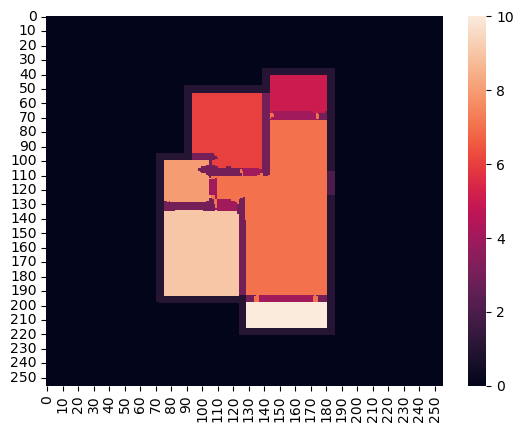

In [17]:
sns.heatmap(rwb)

In [18]:
def gat_input(node_features, edge_index, edge_attr):
    # Input scaling
    x = torch.from_numpy(node_features).float()
    x[:, :2] /= 256.0
    x[:, 2]  /= 10000.0

    ei = torch.from_numpy(edge_index - 5).long()
    ea = torch.from_numpy(edge_attr.T).float()

    # --- make bidirectional ---
    ei = torch.cat([ei, ei.flip(0)], dim=1)
    ea = torch.cat([ea, ea], dim=1)

    # --- final shape for PyG ---
    ea = ea.T.contiguous()  # [E, 2]

    return Data(
        x=x,
        edge_index=ei,
        edge_attr=ea
    )

In [19]:
input_data = gat_input(node_features, edge_index, edge_attr)
print(input_data.x)
print(input_data.edge_index)
print(input_data.edge_attr)

tensor([[0.6331, 0.2076, 0.0935],
        [0.4572, 0.3011, 0.2191],
        [0.6031, 0.5284, 0.6037],
        [0.3498, 0.4464, 0.0804],
        [0.3884, 0.6399, 0.2849],
        [0.6035, 0.8066, 0.0936]])
tensor([[0, 0, 1, 1, 2, 2, 2, 3, 1, 2, 2, 3, 3, 4, 5, 4],
        [1, 2, 2, 3, 3, 4, 5, 4, 0, 0, 1, 1, 2, 2, 2, 3]])
tensor([[ 0., 14.],
        [ 1., 28.],
        [ 1.,  8.],
        [ 0., 17.],
        [ 1., 11.],
        [ 0., 62.],
        [ 1., 35.],
        [ 0., 30.],
        [ 0., 14.],
        [ 1., 28.],
        [ 1.,  8.],
        [ 0., 17.],
        [ 1., 11.],
        [ 0., 62.],
        [ 1., 35.],
        [ 0., 30.]])


In [20]:
logits = gat_model(input_data)
print(logits.shape)

pred_gat = logits.argmax(dim=-1)
print(pred_gat)

vocab = get_vocab()["object_idx_to_name"]

pred_gat_labels = [vocab[i] for i in pred_gat]
print(pred_gat_labels)

torch.Size([6, 13])
tensor([2, 7, 0, 3, 1, 9])
['Kitchen', 'SecondRoom', 'LivingRoom', 'Bathroom', 'MasterRoom', 'Balcony']


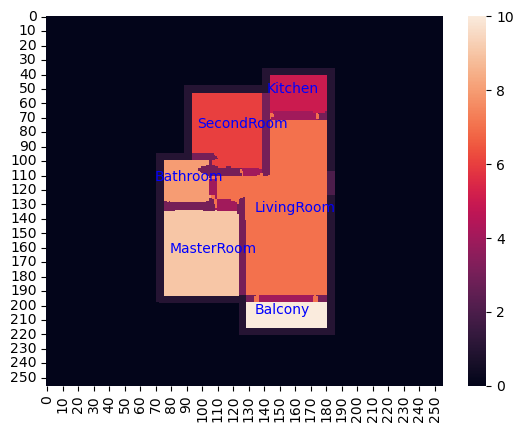

In [21]:
fig, ax = plt.subplots()

sns.heatmap(rwb, ax=ax)

for node, label in zip(node_features, pred_gat_labels):
    ax.text(node[0]-20, node[1], label, color="blue")

# Batch Transform

In [22]:
from torch.utils.data import DataLoader as DataLoaderUtils
from src.train_cnn import ZarrDataset as ZarrDatasetCNN
from time import perf_counter

In [23]:
zarr_path = f'{s3_project_prefix}/store/data.zarr'

val_sample = np.random.choice(val_indices, 5000, replace=False)
val_dataset   = ZarrDatasetCNN(zarr_path, val_sample)
BATCH_SIZE = 16

val_loader = DataLoaderUtils(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
    )

gat_batch_pred = []
batch_durations = []
counter = 0

cnn_model.eval()
gat_model.eval()

with torch.no_grad():
    for batch in val_loader:
        batch_start = perf_counter()

        inside_mask_batch   = batch['inside_mask'].float()
        boundary_mask_batch = batch['boundary_mask'].float()

        # CNN inference on full batch
        pred = cnn_model(inside_mask_batch.to("cpu"), boundary_mask_batch.to("cpu"))

        # Graph extraction must be done per sample
        for i in range(len(inside_mask_batch)):
            # Extract single sample as numpy [H, W]
            inside_mask   = inside_mask_batch[i].squeeze().numpy()
            boundary_mask = boundary_mask_batch[i].squeeze().numpy()

            pred_room = torch.sigmoid(pred['room_mask'][i]).squeeze().detach().numpy()
            pred_door = torch.sigmoid(pred['door_mask'][i]).squeeze().detach().numpy()

            pred_room_bin = model_thresholding(pred_room, 0.20)
            pred_door_bin = model_thresholding(pred_door, 0.15)

            # Graph extraction — all numpy [H, W] now
            stacked_layers = stack_normalize(boundary_mask, pred_room_bin, pred_door_bin)
            num_labels, labels, stats, centroids = conn_components(
                inside_mask, boundary_mask, pred_room_bin, pred_door_bin
            )
            rwb = rooms_with_bounds(stacked_layers, labels)
            adj_graph = extract_all_adjacencies(rwb)
            src, dst, attr = edge_arrays(adj_graph)

            src = np.array(src)
            dst = np.array(dst)

            """ if len(src) > 0:
                min_label = min(src.min(), dst.min())
                src = src - min_label
                dst = dst - min_label """
                
            edge_index = np.array([src, dst])
            edge_attr = np.array(attr)
            node_features = np.array(node_array(centroids[1:, :], stats[1:, :]))

            gat_input_data = gat_input(node_features, edge_index, edge_attr)

            try:
                logits = gat_model(gat_input_data)
                gat_batch_pred.append(logits.argmax(dim=-1))
            except Exception as e:
                print(f"Sample {i} GAT inference failed: {e} | Logits: {logits.shape}")
                continue

        batch_duration = perf_counter() - batch_start
        avg_inference_time = batch_duration / BATCH_SIZE
        counter += 1
        print(f"Batch {counter} | Time: {batch_duration:.2f}s | Avg: {avg_inference_time:.2f}s")

DEBUG init zarr_path: s3://sagemaker-us-east-1-298748835671/floorplan-generator/store/data.zarr


Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7f9ef56dd9d0>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7f9ef557ecf0>, 6333.596711076)])']
connector: <aiohttp.connector.TCPConnector object at 0x7f9ef56dd9a0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7f9eac5881a0>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7f9ef557ec30>, 6333.584869707)])']
connector: <aiohttp.connector.TCPConnector object at 0x7f9eac646840>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7f9ef553dd90>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7f9ef557e9f0>, 6333.589181685)])']
connector: <aiohttp.connector.TCPConnector object at 0x7f9ef56d9c70>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7f9eac5881a0>
Unclosed connector
connectio

Sample 1 GAT inference failed: index 2 is out of bounds for dimension 0 with size 2 | Logits: torch.Size([4, 13])
Sample 4 GAT inference failed: index 2 is out of bounds for dimension 0 with size 2 | Logits: torch.Size([5, 13])
Sample 6 GAT inference failed: index 2 is out of bounds for dimension 0 with size 2 | Logits: torch.Size([6, 13])
Sample 12 GAT inference failed: index 2 is out of bounds for dimension 0 with size 2 | Logits: torch.Size([3, 13])
Sample 15 GAT inference failed: index 2 is out of bounds for dimension 0 with size 2 | Logits: torch.Size([4, 13])
Batch 1 | Time: 21.52s | Avg: 1.35s
Sample 0 GAT inference failed: index 2 is out of bounds for dimension 0 with size 1 | Logits: torch.Size([4, 13])
Sample 2 GAT inference failed: index 2 is out of bounds for dimension 0 with size 2 | Logits: torch.Size([5, 13])
Sample 4 GAT inference failed: index 2 is out of bounds for dimension 0 with size 2 | Logits: torch.Size([5, 13])
Sample 11 GAT inference failed: index 2 is out of 

/tmp/ipykernel_909/2598649390.py:15: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1741562953549/work/aten/src/ATen/native/TensorShape.cpp:3725.)
  ea = ea.T.contiguous()  # [E, 2]


Sample 4 GAT inference failed: mat1 and mat2 shapes cannot be multiplied (1x1 and 2x256) | Logits: torch.Size([5, 13])
Sample 5 GAT inference failed: index 2 is out of bounds for dimension 0 with size 1 | Logits: torch.Size([5, 13])
Sample 9 GAT inference failed: index 2 is out of bounds for dimension 0 with size 2 | Logits: torch.Size([4, 13])
Sample 12 GAT inference failed: index 2 is out of bounds for dimension 0 with size 2 | Logits: torch.Size([4, 13])
Sample 13 GAT inference failed: index 2 is out of bounds for dimension 0 with size 2 | Logits: torch.Size([4, 13])
Sample 15 GAT inference failed: index 2 is out of bounds for dimension 0 with size 2 | Logits: torch.Size([4, 13])
Batch 5 | Time: 17.79s | Avg: 1.11s
Sample 0 GAT inference failed: index 2 is out of bounds for dimension 0 with size 2 | Logits: torch.Size([4, 13])
Sample 3 GAT inference failed: index 2 is out of bounds for dimension 0 with size 2 | Logits: torch.Size([2, 13])
Sample 5 GAT inference failed: index 2 is ou

In [26]:
len(gat_batch_pred)

3727

In [33]:
len(gat_batch_pred)/5000

0.7454

In [32]:
torch.save(gat_batch_pred, "gat_batch_pred.pt")
np.save("batch_durations.npy", np.array(batch_durations))